# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Event Study for ASVI

---
## Foreword

In this notebook, my goal is first to conduct an event study for abnormal SVI measure around potential inclusion in the top mover list and to explore the potential causal relationship between a stock included in the top mover list of Robinhood and its associated Google search volume index.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels import OLS
from linearmodels.panel import PanelOLS

Then I load the data.

In [2]:
main = pd.read_csv("../../../data/processed/attention_sample.csv", parse_dates=["date"])

# sort by ticker and date
main = main.sort_values(["ticker", "date"]).reset_index(drop=True)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_1743/3875421041.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  main = pd.read_csv("../../../data/processed/attention_sample.csv", parse_dates=["date"])


## 2. Event Study

I define eligible events.

In [3]:
df = main.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# overnight return: close(t-1) to open(t)
df["close_lag1"] = df.groupby("ticker")["close_price"].shift(1)
df["overnight_ret"] = (df["open_price"] - df["close_lag1"]) / df["close_lag1"]
df["abs_overnight_ret"] = df["overnight_ret"].abs()

# market cap at market open in millions
df['shrout_lag1'] = df.groupby('ticker')['shrout'].shift(1)
df['mktcap'] = (df['open_price'] * df['shrout_lag1']) / 1e3

# adjustable market-cap threshold
mcap_cutoff = 300  # example: 300 million
df["eligible"] = df["mktcap"] >= mcap_cutoff

# rank by absolute overnight return within each date, only among eligible stocks
df["rank_abs_overnight"] = (
    df.loc[df["eligible"]]
      .groupby("date")["abs_overnight_ret"]
      .rank(method="first", ascending=False)
)

# event indicator
df["event_raw"] = (
    (df["eligible"]) &
    (df["rank_abs_overnight"] <= 20)
).astype(int)

# event pos and event neg
df["event_pos_raw"] = ((df["event_raw"] == 1) & (df["overnight_ret"] > 0)).astype(int)
df["event_neg_raw"] = ((df["event_raw"] == 1) & (df["overnight_ret"] < 0)).astype(int)

# present value of asvi (non-lagged)
df['asvi_present'] = df.groupby('ticker')['asvi'].shift(-1)


Next, I isolate events so no stock contributes overlapping events within the $[-10,+10]$ window.

In [4]:
WINDOW = 10

def isolate_events(group, event_col="event_raw", window=10):
    g = group.copy()
    event_idx = np.flatnonzero(g[event_col].to_numpy() == 1)
    keep = np.zeros(len(g), dtype=int)

    last_kept = -10**9
    for idx in event_idx:
        # keep the first event, then require distance > window on both sides
        if idx - last_kept > 2 * window:
            keep[idx] = 1
            last_kept = idx

    out = pd.Series(keep, index=g.index, name=f"{event_col}_isolated")
    return out

df["event"] = (
    df.groupby("ticker", group_keys=False)
      .apply(lambda g: isolate_events(g, event_col="event_raw", window=WINDOW))
)

df["event_pos"] = (
    df.groupby("ticker", group_keys=False)
      .apply(lambda g: isolate_events(g, event_col="event_pos_raw", window=WINDOW))
)

df["event_neg"] = (
    df.groupby("ticker", group_keys=False)
      .apply(lambda g: isolate_events(g, event_col="event_neg_raw", window=WINDOW))
)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_1743/4249006469.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: isolate_events(g, event_col="event_raw", window=WINDOW))
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_1743/4249006469.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: isolate_events(g, event_col="event_pos_raw", window=WINDOW))
/v

Now I create the stacked event-time data set.

In [5]:
def build_event_stack(data, event_col="event", window=10):
    data = data.copy()
    event_rows = data.loc[data[event_col] == 1, ["ticker", "date"]].copy()
    event_rows = event_rows.reset_index(drop=True)
    event_rows["event_id"] = np.arange(len(event_rows))

    # assign within-ticker row number to enable fast matching
    data["td_idx"] = data.groupby("ticker").cumcount()
    event_rows = event_rows.merge(
        data[["ticker", "date", "td_idx"]],
        on=["ticker", "date"],
        how="left"
    )

    pieces = []
    for k in range(-window, window + 1):
        tmp = event_rows[["event_id", "ticker", "date", "td_idx"]].copy()
        tmp["rel_time"] = k
        tmp["td_idx"] = tmp["td_idx"] + k
        pieces.append(tmp)

    stack = pd.concat(pieces, ignore_index=True)

    stack = stack.merge(
        data[["ticker", "td_idx", "date", "asvi_present", "overnight_ret", "abs_overnight_ret"]],
        on=["ticker", "td_idx"],
        how="left",
        suffixes=("_event", "")
    )

    # event date is date_event, actual observation date is date
    stack = stack.rename(columns={"date_event": "event_date", "date": "calendar_date"})

    # drop incomplete windows
    counts = stack.groupby("event_id")["asvi_present"].transform("count")
    stack = stack.loc[counts == (2 * window + 1)].copy()

    return stack

stack_all = build_event_stack(df, event_col="event", window=WINDOW)
stack_pos = build_event_stack(df, event_col="event_pos", window=WINDOW)
stack_neg = build_event_stack(df, event_col="event_neg", window=WINDOW)

The first figure is the raw event-time mean of ASVI.

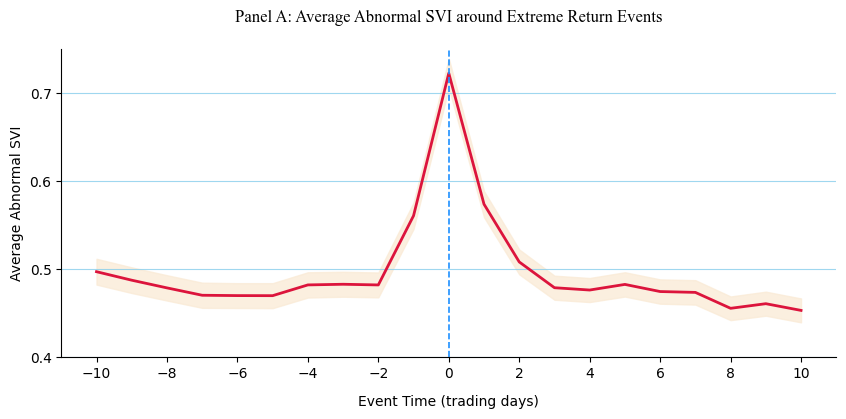

In [11]:
def summarize_event_means(stack):
    out = (
        stack.groupby("rel_time")["asvi_present"]
             .agg(["mean", "std", "count"])
             .reset_index()
    )
    out["se"] = out["std"] / np.sqrt(out["count"])
    out["ci_low"] = out["mean"] - 1.645 * out["se"]
    out["ci_high"] = out["mean"] + 1.645 * out["se"]
    return out

plot_df = summarize_event_means(stack_all)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(plot_df["rel_time"], plot_df["mean"], linewidth=2.0, color="crimson")
ax.fill_between(
    plot_df["rel_time"],
    plot_df["ci_low"],
    plot_df["ci_high"],
    alpha=0.8,
    color="antiquewhite"
)

ax.axvline(0, linestyle="--", linewidth=1.2, color="dodgerblue")
ax.axhline(0, linestyle=":", linewidth=1.0)

ax.set_xlabel("Event Time (trading days)", labelpad=10)
ax.set_ylabel("Average Abnormal SVI")
ax.set_title("Panel A: Average Abnormal SVI around Extreme Return Events", fontsize = 12, pad = 20, family="Times New Roman")
ax.set_xticks(range(-WINDOW, WINDOW + 1, 2))
ax.set_ylim(0.4, 0.75)
ax.set_yticks(np.arange(0.4, 0.8, 0.1))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.8, color='skyblue')
plt.savefig("../../../figures/PanelA_eventStudy_returns.pdf", bbox_inches="tight")
plt.show()

Here, asvi is defined as:

$$
\textit{asvi}_{i, t} = \ln\left(1 + \frac{\textit{svi}_{i, t}}{\frac{1}{20} \sum_{\tau = 1}^{20}\textit{svi}_{i, t - \tau}}\right)
$$

Then I perform the regression:

In [7]:
from linearmodels.iv.absorbing import AbsorbingLS
import pandas as pd
import numpy as np

def run_event_time_regression(stack, reference_period=-1):
    reg = stack.copy()

    # keep only complete cases needed for the regression
    reg = reg.dropna(subset=["asvi_present", "rel_time", "event_id", "calendar_date"]).copy()

    # relative-time dummies excluding reference period
    rel_times = sorted(reg["rel_time"].unique())
    rel_times = [k for k in rel_times if k != reference_period]

    X = pd.DataFrame(index=reg.index)
    for k in rel_times:
        X[f"rt_{k}"] = (reg["rel_time"] == k).astype(float)

    y = reg["asvi_present"].astype(float)

    # absorbed fixed effects must be categorical / string / numeric
    absorb = pd.DataFrame({
        "event_id": reg["event_id"].astype("category"),
        "calendar_date": reg["calendar_date"].astype("category")
    }, index=reg.index)

    # two-way clustering by event and calendar date
    clusters = pd.DataFrame({
        "event_cluster": reg["event_id"],
        "date_cluster": reg["calendar_date"].factorize()[0]
    }, index=reg.index)

    model = AbsorbingLS(y, X, absorb=absorb)
    res = model.fit(cov_type="clustered", clusters=clusters)

    coef = res.params.copy()
    se = res.std_errors.copy()

    out = pd.DataFrame({
        "rel_time": rel_times,
        "coef": [coef[f"rt_{k}"] for k in rel_times],
        "se": [se[f"rt_{k}"] for k in rel_times]
    })

    out["ci_low"] = out["coef"] - 1.96 * out["se"]
    out["ci_high"] = out["coef"] + 1.96 * out["se"]

    baseline = pd.DataFrame({
        "rel_time": [reference_period],
        "coef": [0.0],
        "se": [0.0],
        "ci_low": [0.0],
        "ci_high": [0.0]
    })

    out = pd.concat([out, baseline], ignore_index=True).sort_values("rel_time")
    return res, out

res_all, coef_df_all = run_event_time_regression(stack_all, reference_period=-1)
print(res_all.summary)

                         Absorbing LS Estimation Summary                          
Dep. Variable:           asvi_present   R-squared:                          0.0781
Estimator:               Absorbing LS   Adj. R-squared:                     0.0275
No. Observations:              131187   F-statistic:                        630.57
Date:                Sun, Apr 05 2026   P-value (F-stat):                   0.0000
Time:                        13:33:39   Distribution:                     chi2(20)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0076
                                        Variables Absorbed:                 6809.0
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
rt_-10        -0.2100     0.0398    -5.2703     0.0000     -0.2881     -0.1319
rt_-9         -0.203

In [22]:
print("Unique event count:", stack_all["event_id"].nunique())

# number of unique events with positive overnigh return when rel_time = 0
test = stack_all.loc[stack_all["rel_time"] == 0].copy()
test["overnight_ret_positive"] = (test["overnight_ret"] > 0).astype(int)
event_counts = test.groupby("overnight_ret_positive")["event_id"].nunique()
print(event_counts)
stack_all.head()

Unique event count: 6247
overnight_ret_positive
0    2977
1    3270
Name: event_id, dtype: int64


,event_id,ticker,event_date,td_idx,rel_time,calendar_date,asvi_present,overnight_ret,abs_overnight_ret
3,3,A,2020-05-22,497,-10,2020-05-08,0.658858,0.014904,0.014904
4,4,AA,2019-01-17,18,-10,2019-01-03,0.835803,-0.004573,0.004573
6,6,AA,2019-09-11,177,-10,2019-08-27,1.134473,0.008154,0.008154
8,8,AA,2020-07-08,377,-10,2020-06-23,0.579295,0.024514,0.024514
9,9,AAL,2019-01-10,164,-10,2018-12-26,0.472969,0.013459,0.013459


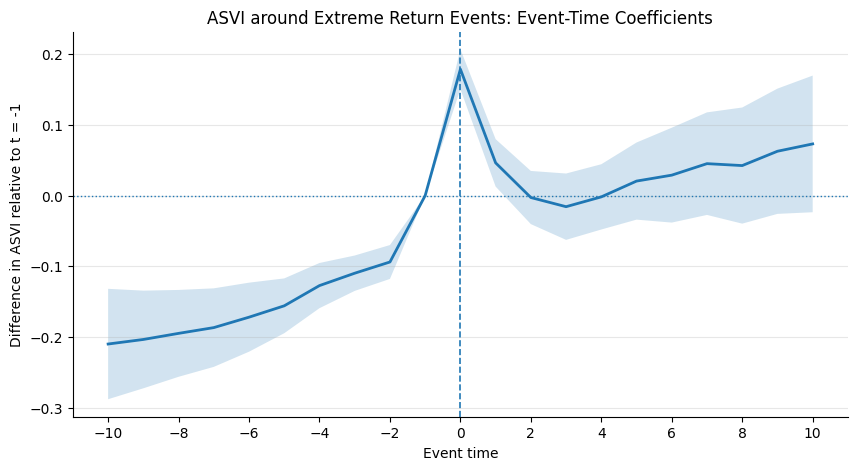

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(coef_df_all["rel_time"], coef_df_all["coef"], linewidth=2.0)
ax.fill_between(
    coef_df_all["rel_time"],
    coef_df_all["ci_low"],
    coef_df_all["ci_high"],
    alpha=0.2
)

ax.axvline(0, linestyle="--", linewidth=1.2)
ax.axhline(0, linestyle=":", linewidth=1.0)

ax.set_xlabel("Event time")
ax.set_ylabel("Difference in ASVI relative to t = -1")
ax.set_title("ASVI around Extreme Return Events: Event-Time Coefficients")
ax.set_xticks(range(-WINDOW, WINDOW + 1, 2))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.show()

In [9]:
res_pos, coef_df_pos = run_event_time_regression(stack_pos, reference_period=-1)
res_neg, coef_df_neg = run_event_time_regression(stack_neg, reference_period=-1)

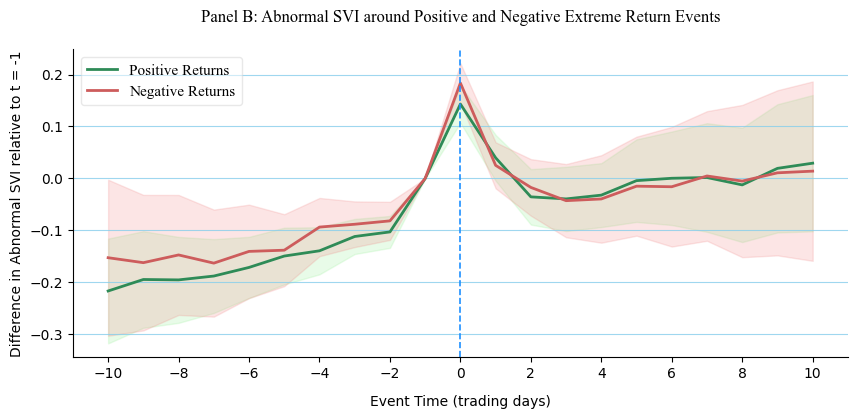

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

# positive events
ax.plot(
    coef_df_pos["rel_time"],
    coef_df_pos["coef"],
    linewidth=2.0,
    label="Positive Returns",
    color="seagreen"
)
ax.fill_between(
    coef_df_pos["rel_time"],
    coef_df_pos["ci_low"],
    coef_df_pos["ci_high"],
    alpha=0.2,
    color="lightgreen"
)

# negative events
ax.plot(
    coef_df_neg["rel_time"],
    coef_df_neg["coef"],
    linewidth=2.0,
    label="Negative Returns",
    color="indianred"
)
ax.fill_between(
    coef_df_neg["rel_time"],
    coef_df_neg["ci_low"],
    coef_df_neg["ci_high"],
    alpha=0.2,
    color="lightcoral"
)

ax.axvline(0, linestyle="--", linewidth=1.2, color="dodgerblue")

ax.set_xlabel("Event Time (trading days)", labelpad=10)
ax.set_ylabel("Difference in Abnormal SVI relative to t = -1")
ax.set_title("Panel B: Abnormal SVI around Positive and Negative Extreme Return Events", fontsize = 12, pad = 20, family="Times New Roman")
ax.set_xticks(range(-WINDOW, WINDOW + 1, 2))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.8, color='skyblue')
ax.legend(frameon=True, facecolor="white", edgecolor="lightgrey", loc="upper left",
          framealpha=0.5, prop={"family": "Times New Roman", "size": 11})
plt.savefig("../../../figures/PanelB_eventStudy_returns.pdf", bbox_inches="tight")
plt.show()

In [16]:
print(res_pos.summary)

                         Absorbing LS Estimation Summary                          
Dep. Variable:           asvi_present   R-squared:                          0.0843
Estimator:               Absorbing LS   Adj. R-squared:                     0.0310
No. Observations:               78603   F-statistic:                        410.45
Date:                Sun, Apr 05 2026   P-value (F-stat):                   0.0000
Time:                        13:38:19   Distribution:                     chi2(20)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0076
                                        Variables Absorbed:                 4305.0
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
rt_-10        -0.2168     0.0515    -4.2106     0.0000     -0.3177     -0.1159
rt_-9         -0.194

In [17]:
print(res_neg.summary)

                         Absorbing LS Estimation Summary                          
Dep. Variable:           asvi_present   R-squared:                          0.0837
Estimator:               Absorbing LS   Adj. R-squared:                     0.0298
No. Observations:               72849   F-statistic:                        395.84
Date:                Sun, Apr 05 2026   P-value (F-stat):                   0.0000
Time:                        13:40:01   Distribution:                     chi2(20)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0080
                                        Variables Absorbed:                 4031.0
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
rt_-10        -0.1527     0.0766    -1.9932     0.0462     -0.3029     -0.0025
rt_-9         -0.162

The regression is normalized to $t=-1$. So every coefficient measures the difference in ASVI at event time $k$ relative to the day immediately before the extreme overnight return event.

The main result is the coefficient at $t=0: 0.1788$, highly significant. This means abnormal search attention jumps sharply on the event day itself relative to $t=-1$. That is the core finding. Search attention is not merely elevated in a vague neighborhood of the event; it spikes discretely when the extreme return shock occurs.

The second key feature is the entire pre-event path. From $t=-10$ to $t=-2$, all coefficients are negative and strongly significant, and they become less negative as the event approaches. This means ASVI is systematically lower in the days leading up to the event than on day $-1$. Put differently, there is a strong run-up in attention before the event, but that run-up is concentrated very late, essentially between $-2$, $-1$, and $0$. So the evidence does not support a long, gradual anticipatory build-up in search attention over many days. Instead, it suggests that attention remains relatively subdued until shortly before the event and then accelerates sharply into the event date.

Post-event dynamics are much weaker. At $t=1$, the coefficient is still positive, $0.0463$, and statistically significant, so some elevated attention persists one day after the event. But from $t=2$ onward, the coefficients are small and statistically insignificant. That indicates the search spike is short-lived. The event seems to trigger a contemporaneous burst of attention, followed by quick normalization rather than a prolonged attention regime.

That interpretation is fully consistent with Panel A. In levels, average ASVI is fairly flat before the event, then jumps sharply at $t=0$, and then falls back quickly. The plot gives the visual impression of a narrow attention spike rather than a broad hump. That is exactly what the regression confirms.

Panel B adds an important nuance. Positive and negative extreme return events both display the same broad pattern: a strong spike at $t=0$, little persistence afterward, and no evidence of a long anticipatory phase. So the contemporaneous attention response is not confined to one sign of return shock. Both large gains and large losses attract abnormal search.

There are, however, some asymmetries. Before the event, the green line for positive returns lies somewhat below the red line for negative returns at longer negative horizons, suggesting that search attention is especially low far in advance of large positive overnight moves. Around the event date itself, both series jump, with the red line for negative events appearing somewhat higher at $t=0$, though the confidence bands overlap substantially. So visually, negative shocks may induce a slightly stronger immediate search response, but the graph does not suggest a dramatic asymmetry.

MORE CONCISE:

The figure shows that abnormal Google search intensity rises sharply around extreme overnight return events. Relative to day -1, ASVI is significantly lower throughout the earlier pre-event window, indicating that the increase in attention is concentrated in the immediate run-up to the event rather than building gradually over many days. On the event day itself, ASVI exhibits a pronounced and highly significant spike, after which attention falls back rapidly and becomes statistically indistinguishable from its day -1 level within two trading days. The same qualitative pattern holds for both positive and negative return shocks, suggesting that extreme price movements of either sign trigger a contemporaneous burst of investor attention. Overall, the evidence is more consistent with search attention behaving as a manifestation of stock salience at the time of the shock than as a long-horizon anticipatory signal.